# Tutorial 1: Continual Integration of Multimodal Mosaic Single-Cell Data

This tutorial shows how to use MIRACLE for continual integration of three multimodal MuData tasks. The tasks arrive in order (`step1`, `step2`, and `step3`) and contain different modality combinations.

The goal is to add each new task without retraining from scratch on the full historical dataset. MIRACLE does this by carrying a compact replay set from the previous stage into the next training stage.

After completing the tutorial, you will be able to:

- Train MIRACLE on an initial MuData task.
- Continue training with a new task and replay data from earlier tasks.
- Extract the joint latent representation from each trained checkpoint.
- Visualize integrated embeddings with UMAP.
- Build and save replay MuData objects for later continual-integration steps.

## Before You Start

This notebook expects the DOTEA MuData files under `data/DOTEA_mudata`. If the files are not present, the configuration cell will download and extract `DOTEA_mudata.tar.gz` automatically. Set `MIRACLE_DATA_BASE_URL` to the public base URL that hosts the archives before running the notebook.

Training can run on GPU when CUDA is available. Adjust `CUDA_VISIBLE_DEVICES`, `BATCH_SIZE`, `EPOCHS`, and `REPLAY_SIZE` for your hardware and experiment size.

## Workflow

Each continual-learning stage follows the same pattern: train or continue the model, extract the joint latent space, visualize the embedding, and write a replay set for the next stage.

```text
step1 -> replay_step1
step2 + replay_step1 -> replay_step2
step3 + replay_step2 -> replay_step3
```


In [1]:
# Standard imports and project setup
import json
import os
import sys
from pathlib import Path

# Respect externally configured CUDA devices; otherwise default to GPU 1.
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '1')

import torch
import matplotlib.pyplot as plt
import mudata as mu
import numpy as np
import pandas as pd
import scanpy as sc

from scmiracle.model import MIRACLE
from scmiracle.download_data import download as download_data

sc.settings.set_figure_params(figsize=(3, 3), dpi=110)


## Configuration and Input Data

Set the core training parameters, create the output directory, and load the three task-specific MuData files. The random seed keeps sampling and training setup reproducible across runs.


In [2]:
SEED = 0
BATCH_SIZE = 256
EPOCHS = 500
REPLAY_SIZE = 5000
DATA_ROOT = os.path.join('data', 'DOTEA_mudata')
SAVE_DIR = os.path.join('results', 'demo1_my_3step')
os.makedirs(SAVE_DIR, exist_ok=True)
ACCELERATOR = 'gpu' if torch.cuda.is_available() else 'cpu'
DEVICES = 1

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

required_files = [
    os.path.join(DATA_ROOT, 'DOTEA_step1.h5mu'),
    os.path.join(DATA_ROOT, 'DOTEA_step2.h5mu'),
    os.path.join(DATA_ROOT, 'DOTEA_step3.h5mu'),
]
if not all(os.path.exists(path) for path in required_files):
    download_data('DOTEA_mudata', 'data')

data1 = mu.read_h5mu(os.path.join(DATA_ROOT, 'DOTEA_step1.h5mu'))
data2 = mu.read_h5mu(os.path.join(DATA_ROOT, 'DOTEA_step2.h5mu'))
data3 = mu.read_h5mu(os.path.join(DATA_ROOT, 'DOTEA_step3.h5mu'))

print('step1:', data1)
print('step2:', data2)
print('step3:', data3)


/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/io.py:408: UserWarning: The HDF5 file was not created by muon/mudata, we can't guarantee that everything will work correctly
  warn(
/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var met

step1: MuData object with n_obs × n_vars = 9579 × 31995
  obs:	'batch', 'label'
  uns:	'_miracle_replay_meta', 'feat_dims', 'feature_names'
  2 modalities
    atac:	9579 x 31787
      obs:	'batch', 'label'
    adt:	9579 x 208
      obs:	'batch', 'label'
      uns:	'mask_subset_0'
step2: MuData object with n_obs × n_vars = 9096 × 35839
  obs:	'batch', 'label'
  uns:	'feat_dims', 'feature_names'
  2 modalities
    atac:	9096 x 31787
      obs:	'batch', 'label'
    rna:	9096 x 4052
      obs:	'batch', 'label'
      uns:	'mask_subset_0'
step3: MuData object with n_obs × n_vars = 7318 × 5167
  obs:	'batch', 'label'
  uns:	'feat_dims', 'feature_names'
  2 modalities
    rna:	7318 x 4959
      obs:	'batch', 'label'
      uns:	'mask_subset_0'
    adt:	7318 x 208
      obs:	'batch', 'label'
      uns:	'mask_subset_0'


/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


## Step 1: Train the Initial Task

The first task establishes the baseline MIRACLE model. `setup_mudata` registers the modalities, feature dimensions, masks, and observation metadata before training starts.


In [3]:
task1_dir = os.path.join(SAVE_DIR, 'task1')
miracle = MIRACLE(batch_size=BATCH_SIZE, save_model_path=task1_dir)

miracle.setup_mudata(data1)
miracle.train(max_epochs=EPOCHS, accelerator=ACCELERATOR, devices=DEVICES)
miracle.save(task1_dir, overwrite=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [1]

  | Name | Type          | Params | Mode 
-----------------------------------------------
0 | net  | VAE           | 10.5 M | train
1 | dsc  | Discriminator | 38.8 K | train
-----------------------------------------------
10.6 M    Trainable params
0         Non-trainable params
10.6 M    Total params
42.258    Total estimated model params size (MB)
640       Modules in train mode
0         Modules in eval mode
/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (38) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 499: 100%|██████████| 38/38 [00:05<00:00,  7.02it/s, v_num=4, loss_/recon_loss_step=9.81e+3, loss_/kld_loss_step=99.50, loss_/consistency_loss_step=22.00, loss/net_step=9.93e+3, loss/dsc_step=0.000, loss_/recon_loss_epoch=9.64e+3, loss_/kld_loss_epoch=98.60, loss_/consistency_loss_epoch=23.70, loss/net_epoch=9.77e+3, loss/dsc_epoch=0.000]

`Trainer.fit` stopped: `max_epochs=500` reached.


Epoch 499: 100%|██████████| 38/38 [00:05<00:00,  6.51it/s, v_num=4, loss_/recon_loss_step=9.81e+3, loss_/kld_loss_step=99.50, loss_/consistency_loss_step=22.00, loss/net_step=9.93e+3, loss/dsc_step=0.000, loss_/recon_loss_epoch=9.64e+3, loss_/kld_loss_epoch=98.60, loss_/consistency_loss_epoch=23.70, loss/net_epoch=9.77e+3, loss/dsc_epoch=0.000]


'results/demo1_my_3step/task1'

### Inspect the Joint Latent Space

After training, extract the joint latent representation from the model.
Use the first 32 latent dimensions for a compact UMAP visualization.


/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


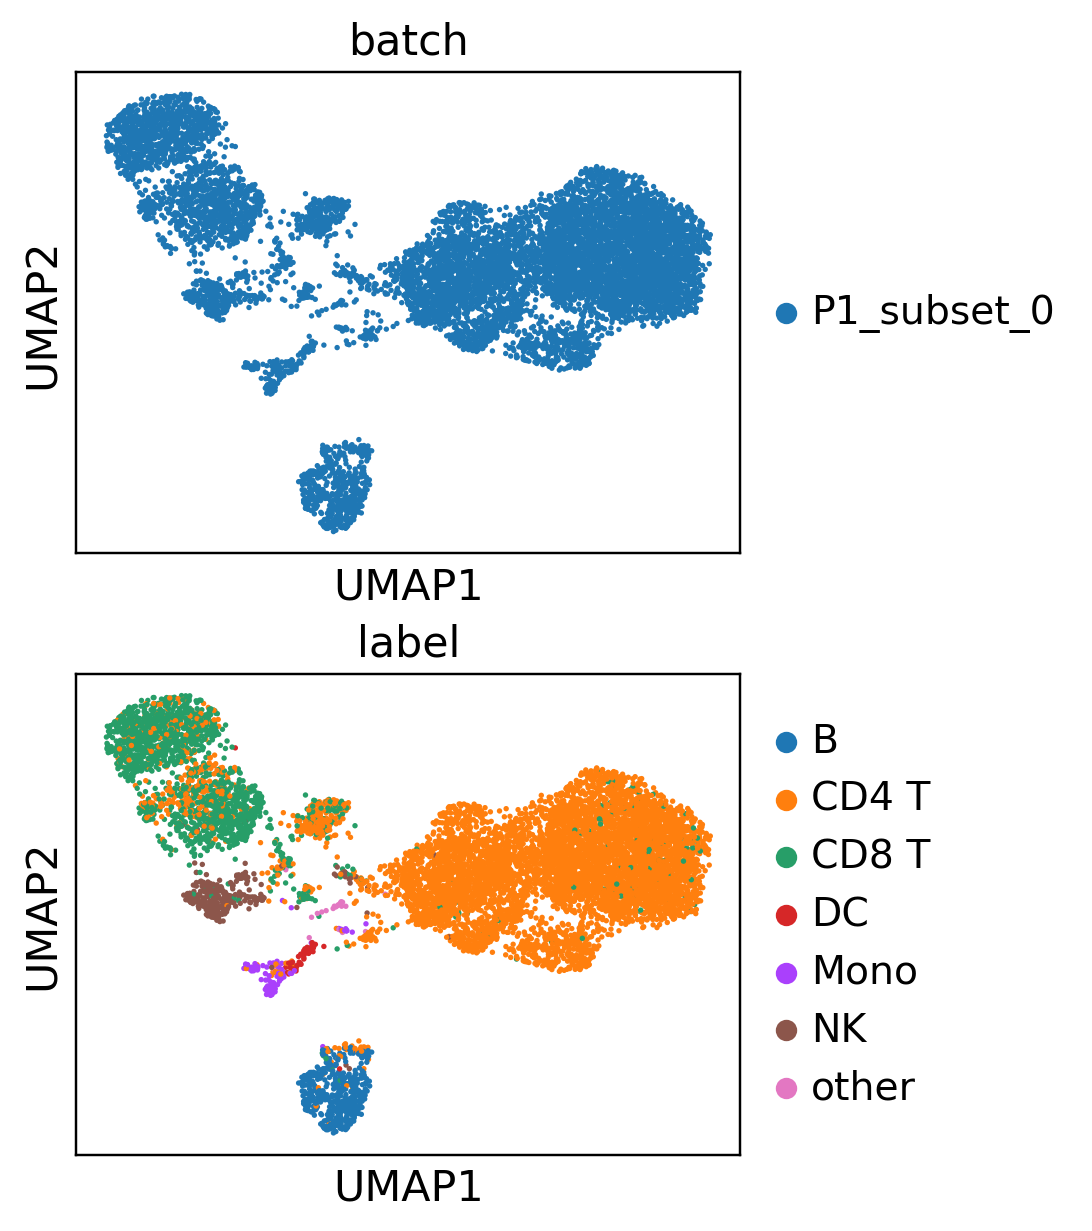

In [4]:
latent1 = miracle.get_latent_representation(data1, kind='joint')
np.savez_compressed(os.path.join(task1_dir, 'latent_joint.npz'), latent=latent1)

adata1 = sc.AnnData(latent1[:, :32])
adata1.obs = data1.obs.copy()
sc.pp.neighbors(adata1)
sc.tl.umap(adata1)
sc.pl.umap(adata1, color=['batch', 'label'], wspace=0.4, ncols=1)


### Build Replay Data

MIRACLE selects a representative subset from the first task and stores it as replay memory.
This replay MuData object is passed to step 2 so the model retains information about earlier data.


In [5]:
replay1 = miracle.build_replay(
    replay_size=REPLAY_SIZE,
    source_mdata=data1,
    latent=latent1,
    strategy='subsample',
)
replay1.write_h5mu(os.path.join(SAVE_DIR, 'replay_step1.h5mu'))

print(replay1)



/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .updat

MuData object with n_obs × n_vars = 5000 × 31995
  uns:	'feat_dims', '_miracle_replay_meta'
  2 modalities
    atac:	5000 x 31787
      obs:	'batch', 'label'
    adt:	5000 x 208
      obs:	'batch', 'label'
      uns:	'mask_subset_0'


/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


## Step 2: Continue Training with the Second Task

Load the replay set from step 1, initialize MIRACLE from the step-1 checkpoint, and train on the second task together with replay data. This is the first continual-learning update.


In [6]:
replay1 = miracle.load_replay(
    os.path.join(SAVE_DIR, 'replay_step1.h5mu'),
)

task2_dir = os.path.join(SAVE_DIR, 'task2')
miracle = MIRACLE(batch_size=BATCH_SIZE, save_model_path=task2_dir)
miracle.setup_continual(
    current_mdata=data2,
    replay_mdata=replay1,
    prev_model_dir=task1_dir,
)
miracle.train(max_epochs=EPOCHS, accelerator=ACCELERATOR, devices=DEVICES)
miracle.save(task2_dir, overwrite=True)


/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .updat

Epoch 499: 100%|██████████| 72/72 [00:05<00:00, 12.07it/s, v_num=6, loss_/recon_loss_step=9.33e+3, loss_/kld_loss_step=100.0, loss_/consistency_loss_step=20.50, loss/net_step=4.83e+3, loss/dsc_step=37.30, loss_/recon_loss_epoch=1.04e+4, loss_/kld_loss_epoch=100.0, loss_/consistency_loss_epoch=22.70, loss/net_epoch=5.23e+3, loss/dsc_epoch=38.50]

`Trainer.fit` stopped: `max_epochs=500` reached.


Epoch 499: 100%|██████████| 72/72 [00:06<00:00, 10.92it/s, v_num=6, loss_/recon_loss_step=9.33e+3, loss_/kld_loss_step=100.0, loss_/consistency_loss_step=20.50, loss/net_step=4.83e+3, loss/dsc_step=37.30, loss_/recon_loss_epoch=1.04e+4, loss_/kld_loss_epoch=100.0, loss_/consistency_loss_epoch=22.70, loss/net_epoch=5.23e+3, loss/dsc_epoch=38.50]


'results/demo1_my_3step/task2'

### Visualize the Accumulated History

After training, evaluate the saved step-2 checkpoint on the full history (`step1 + step2`).
Plotting the full accumulated dataset is more informative than plotting only the replay-augmented training object.


/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .updat

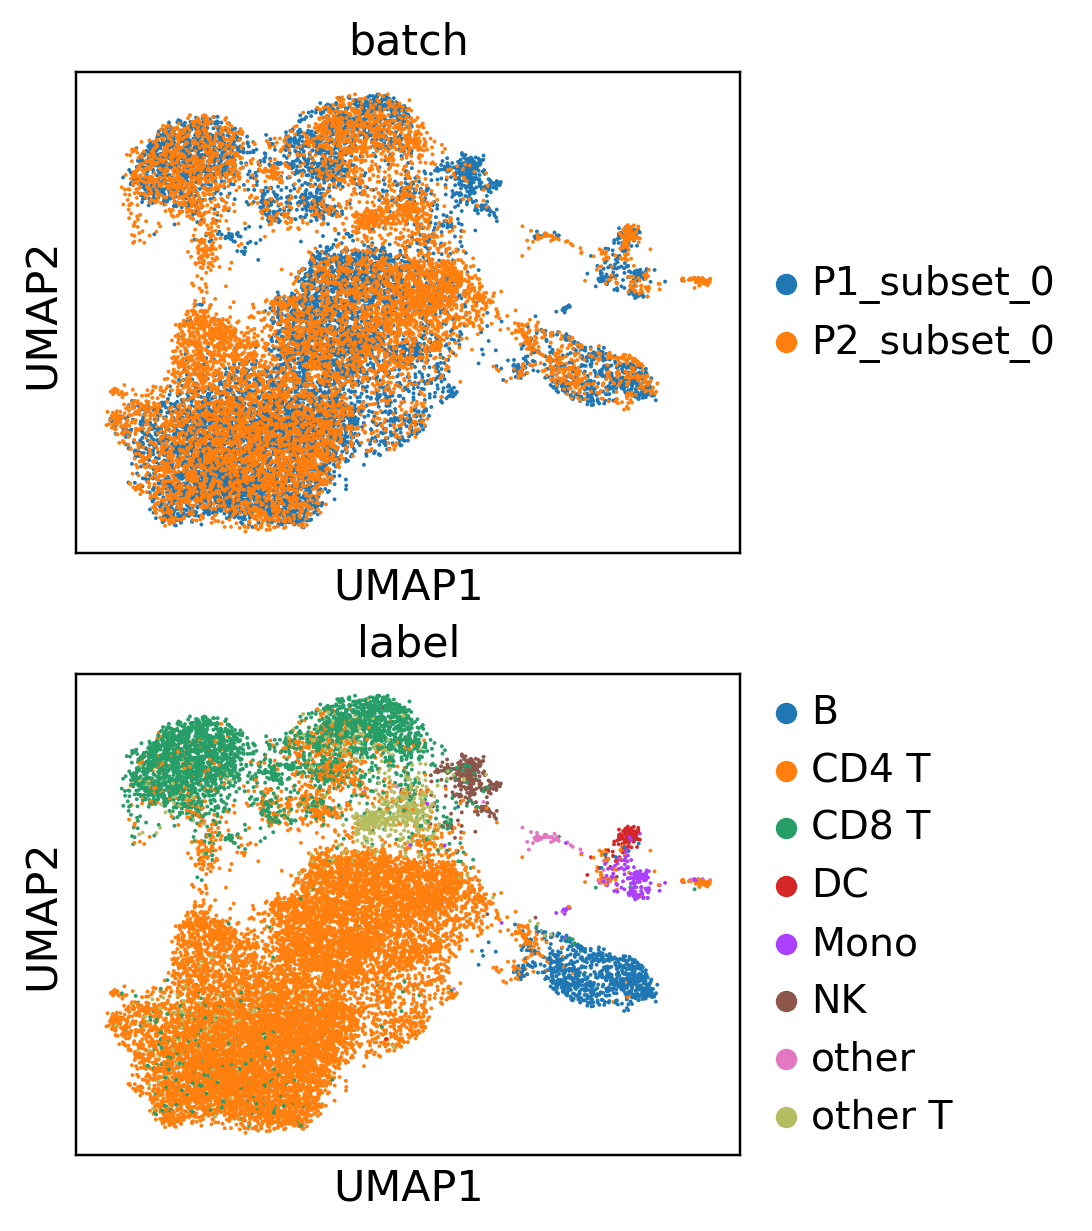

In [7]:
merged2 = MIRACLE._concat_mudata([data1, data2])
latent2 = MIRACLE.get_latent_from_checkpoint(
    merged2,
    task2_dir,
    kind='joint',
    batch_size=BATCH_SIZE,
    batch_key='batch',
)

np.savez_compressed(os.path.join(task2_dir, 'latent_joint.npz'), latent=latent2)

adata2 = sc.AnnData(latent2[:, :32])
adata2.obs['batch'] = MIRACLE.get_obs_series(merged2, 'batch').values
adata2.obs['label'] = MIRACLE.get_obs_series(merged2, 'label').values
sc.pp.neighbors(adata2)
sc.tl.umap(adata2)
sc.pl.umap(adata2, color=['batch', 'label'], wspace=0.4,  ncols=1)


### Update Replay Data

Rebuild replay from the current continual model state.
The updated replay set summarizes the information available after step 2 and becomes the memory used in step 3.


In [8]:
replay2 = miracle.build_replay(
    replay_size=REPLAY_SIZE,
    source_mdata=miracle.model._mdata,
    latent=latent2,
    strategy='subsample',
)
replay2.write_h5mu(os.path.join(SAVE_DIR, 'replay_step2.h5mu'))

print(replay2)

/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .updat

MuData object with n_obs × n_vars = 5000 × 36047
  uns:	'feat_dims', '_miracle_replay_meta'
  3 modalities
    adt:	1774 x 208
      obs:	'batch', 'label'
      uns:	'mask_subset_0'
    atac:	5000 x 31787
      obs:	'batch', 'label'
    rna:	3226 x 4052
      obs:	'batch', 'label'
      uns:	'mask_subset_0'


/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


## Step 3: Continue Training with the Third Task

Repeat the continual-learning update: load replay from step 2, initialize from the step-2 checkpoint, and train on the third task plus replay data.


In [9]:
replay2 = miracle.load_replay(
    os.path.join(SAVE_DIR, 'replay_step2.h5mu'),
)

task3_dir = os.path.join(SAVE_DIR, 'task3')
miracle = MIRACLE(batch_size=BATCH_SIZE, save_model_path=task3_dir)
miracle.setup_continual(
    current_mdata=data3,
    replay_mdata=replay2,
    prev_model_dir=task2_dir,
)
miracle.train(max_epochs=EPOCHS, accelerator=ACCELERATOR, devices=DEVICES)
miracle.save(task3_dir, overwrite=True)


/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .updat

Epoch 499: 100%|██████████| 58/58 [00:04<00:00, 14.15it/s, v_num=7, loss_/recon_loss_step=9.34e+3, loss_/kld_loss_step=105.0, loss_/consistency_loss_step=17.80, loss/net_step=6.93e+3, loss/dsc_step=66.20, loss_/recon_loss_epoch=6.57e+3, loss_/kld_loss_epoch=105.0, loss_/consistency_loss_epoch=22.20, loss/net_epoch=4.11e+3, loss/dsc_epoch=74.00]

`Trainer.fit` stopped: `max_epochs=500` reached.


Epoch 499: 100%|██████████| 58/58 [00:04<00:00, 11.95it/s, v_num=7, loss_/recon_loss_step=9.34e+3, loss_/kld_loss_step=105.0, loss_/consistency_loss_step=17.80, loss/net_step=6.93e+3, loss/dsc_step=66.20, loss_/recon_loss_epoch=6.57e+3, loss_/kld_loss_epoch=105.0, loss_/consistency_loss_epoch=22.20, loss/net_epoch=4.11e+3, loss/dsc_epoch=74.00]


'results/demo1_my_3step/task3'

### Visualize the Full History

Evaluate the step-3 checkpoint on all three tasks (`step1 + step2 + step3`).
This final UMAP summarizes the joint latent space learned by the complete three-stage pipeline.


/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/root/anaconda3/envs/scmidas3/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .updat

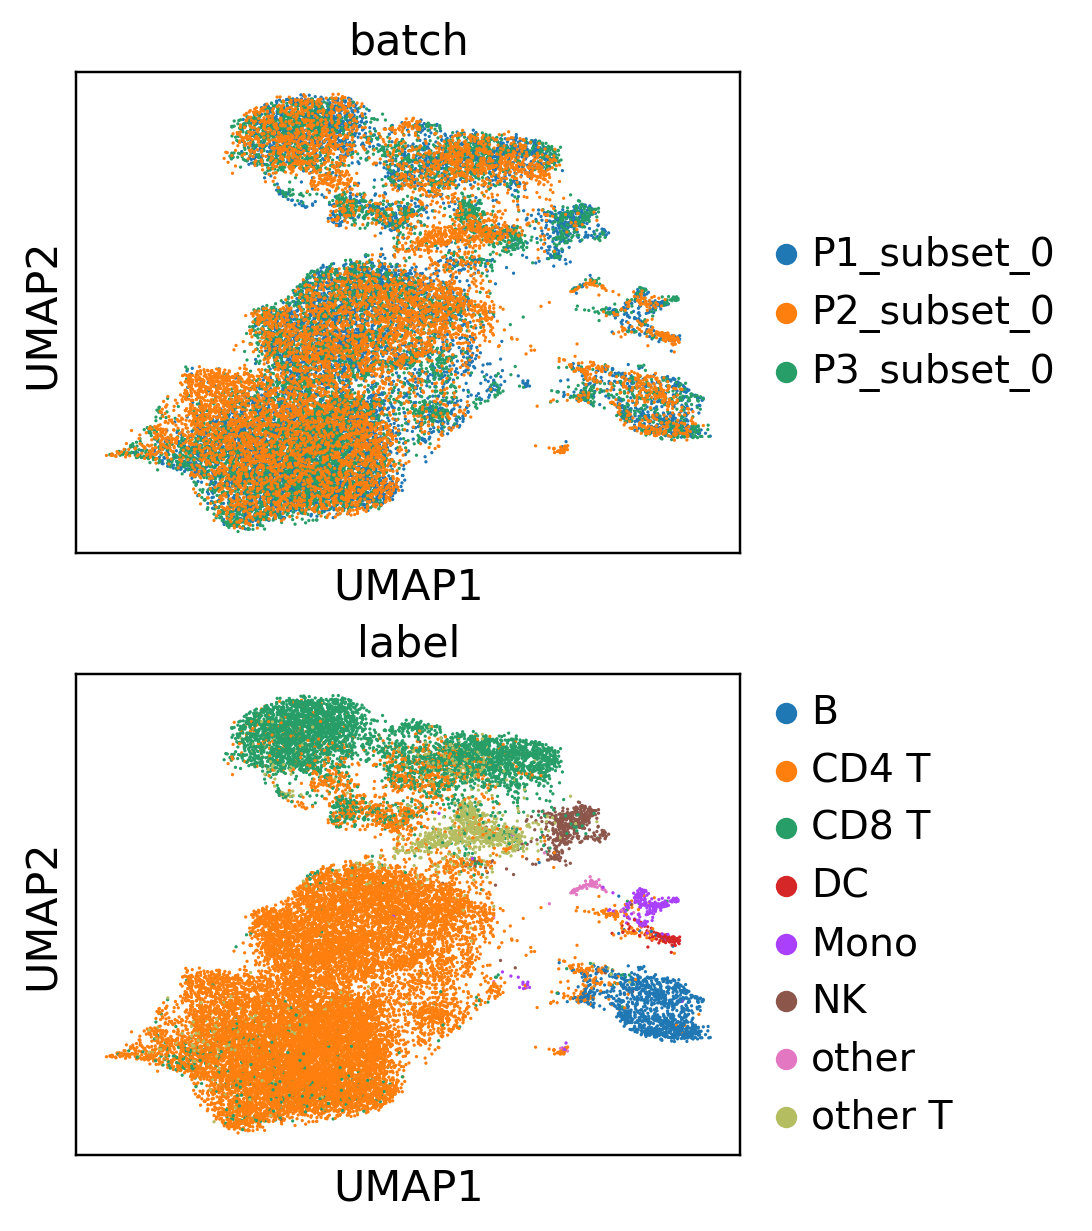

In [10]:
merged3 = MIRACLE._concat_mudata([data1, data2, data3])
latent3 = MIRACLE.get_latent_from_checkpoint(
    merged3,
    task3_dir,
    kind='joint',
    batch_size=BATCH_SIZE,
    batch_key='batch',
)

np.savez_compressed(os.path.join(task3_dir, 'latent_joint.npz'), latent=latent3)

adata3 = sc.AnnData(latent3[:, :32])
adata3.obs['batch'] = MIRACLE.get_obs_series(merged3, 'batch').values
adata3.obs['label'] = MIRACLE.get_obs_series(merged3, 'label').values
sc.pp.neighbors(adata3)
sc.tl.umap(adata3)
sc.pl.umap(adata3, color=['batch', 'label'], wspace=0.4, ncols=1)


### Export Final Replay Data

Build and save the replay object after step 3.
This file can be inspected directly or reused as the starting memory for additional continual-learning experiments.


In [ ]:
replay3 = miracle.build_replay(
    replay_size=REPLAY_SIZE,
    source_mdata=miracle.model._mdata,
    latent=latent3,
    strategy='subsample',
)
replay3.write_h5mu(os.path.join(SAVE_DIR, 'replay_step3.h5mu'))